# Lotka-Volterra AI Simulator - Analysis
**Author:** Kokouvi Ferdinand DJATA (Ferdio AI Vision)

**Objectives**
1. Simulate predator-prey dynamics by numerical integration and check the solver against the model's conserved quantity.
2. Compare simple models for one-step-ahead prediction, against a persistence baseline, on the training orbit **and on orbits never seen in training**.
3. Fit the model to the Hudson Bay lynx-hare series and validate the fit on held-out years.

**Stack:** scipy, numpy, pandas, scikit-learn, matplotlib

## 1. Model

$$\frac{dx}{dt} = \alpha x - \beta x y \qquad \frac{dy}{dt} = \delta x y - \gamma y$$

$x$ = prey, $y$ = predator. The system is autonomous and non-linear. It has a non-trivial equilibrium $(\gamma/\delta,\ \alpha/\beta)$ and the quantity

$$H(x,y) = \delta x - \gamma \ln x + \beta y - \alpha \ln y$$

is constant along every solution, so orbits are closed level curves of $H$: a **family of neutrally stable closed orbits** (a centre), not limit cycles. Each initial condition gives its own orbit. RK45 (Dormand-Prince) does not preserve $H$ exactly, so its drift is a direct measure of numerical accuracy.

In [1]:
import sys
from pathlib import Path
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from simulation import LotkaVolterraParams, simulate, generate_noisy_dataset, invariant_drift, clipped_fraction
from ai_model import (create_supervised_dataset, train_and_evaluate, unseen_orbit_evaluation,
                      results_to_frame, PERSISTENCE, LINEAR, FOREST)
from real_data_validation import load_real_data, fit_lotka_volterra, holdout_check, plot_fit

FIG = Path('../figures'); FIG.mkdir(exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

## 2. Simulation

The initial state (10, 5) is close to the equilibrium (4, 2.75), so populations stay at meaningful levels. (Starting from (40, 9), the prey would spend most of the time below 0.1, which makes the data mostly noise floor.)

In [2]:
params = LotkaVolterraParams()          # alpha=1.1, beta=0.4, delta=0.1, gamma=0.4, x0=10, y0=5
clean_df = simulate(params, t_span=(0, 100), t_eval_points=1000)
noisy_df = generate_noisy_dataset(clean_df, noise_level=0.05, random_seed=42)

print('Equilibrium (prey, predator):', params.equilibrium)
print(clean_df[['prey', 'predator']].describe().round(3))
d = invariant_drift(params, clean_df)
print(f"\nInvariant H0 = {d['h0']:.4f}; max |H - H0| = {d['max_abs']:.2e} (relative {d['max_rel']:.2e})")
print(f"Noisy observations clipped at the lower bound: {100 * clipped_fraction(noisy_df):.2f}%")

Equilibrium (prey, predator): (4.0, 2.75)
           prey  predator
count  1000.000  1000.000
mean      3.968     2.823
std       4.196     1.781
min       0.509     0.916
25%       0.721     1.192
50%       1.822     2.213
75%       6.327     4.352
max      13.676     6.155

Invariant H0 = 0.3086; max |H - H0| = 1.95e-07 (relative 6.33e-07)
Noisy observations clipped at the lower bound: 0.10%


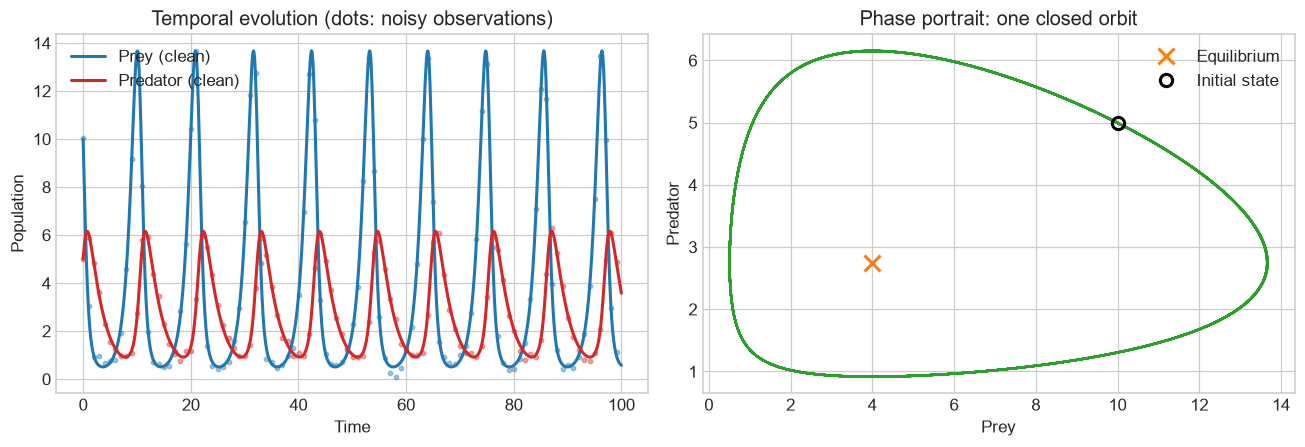

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
ax.plot(clean_df['time'], clean_df['prey'], color='#1f77b4', lw=2, label='Prey (clean)')
ax.plot(clean_df['time'], clean_df['predator'], color='#d62728', lw=2, label='Predator (clean)')
ax.scatter(noisy_df['time'][::10], noisy_df['prey_noisy'][::10], s=8, alpha=0.4, color='#1f77b4')
ax.scatter(noisy_df['time'][::10], noisy_df['predator_noisy'][::10], s=8, alpha=0.4, color='#d62728')
ax.set_xlabel('Time'); ax.set_ylabel('Population'); ax.set_title('Temporal evolution (dots: noisy observations)'); ax.legend()

ax = axes[1]
ax.plot(clean_df['prey'], clean_df['predator'], color='#2ca02c', lw=1.5)
ax.plot(*params.equilibrium, 'x', color='#ff7f0e', ms=10, mew=2, label='Equilibrium')
ax.plot(clean_df['prey'].iloc[0], clean_df['predator'].iloc[0], 'ko', ms=8, fillstyle='none', mew=2, label='Initial state')
ax.set_xlabel('Prey'); ax.set_ylabel('Predator'); ax.set_title('Phase portrait: one closed orbit'); ax.legend()
plt.tight_layout(); plt.savefig(FIG / 'simulation_overview.png', dpi=200); plt.show()

**Result.** The invariant $H$ drifts by at most 2.0e-07 (6.3e-07 relative) over 100 time units: the numerical orbit stays closed to solver accuracy.

## 3. One-step-ahead prediction

Supervised formulation: $[prey(t), predator(t)] \to [prey(t+1), predator(t+1)]$, chronological 80/20 split (no shuffling). Three predictors are compared:

- **Persistence**: predicts that nothing changes. With a time step of about 0.1 consecutive states are nearly identical, so this trivial predictor already has a very high R2. A model is only useful if it beats it.
- **LinearRegression**
- **RandomForestRegressor**

In [4]:
models, results, (X_test, y_test) = train_and_evaluate(noisy_df, verbose=False)
same_orbit = results_to_frame(results)
same_orbit.round(4)

,mse_prey,mse_predator,r2_prey,r2_predator,mse_prey_vs_persistence,mse_predator_vs_persistence
model_name,,,,,,
Persistence (baseline),0.2061,0.0567,0.9888,0.9832,1.0000,1.0000
LinearRegression,0.1221,0.0424,0.9933,0.9874,0.5927,0.7479
RandomForestRegressor,0.0744,0.0343,0.9959,0.9898,0.3612,0.6046


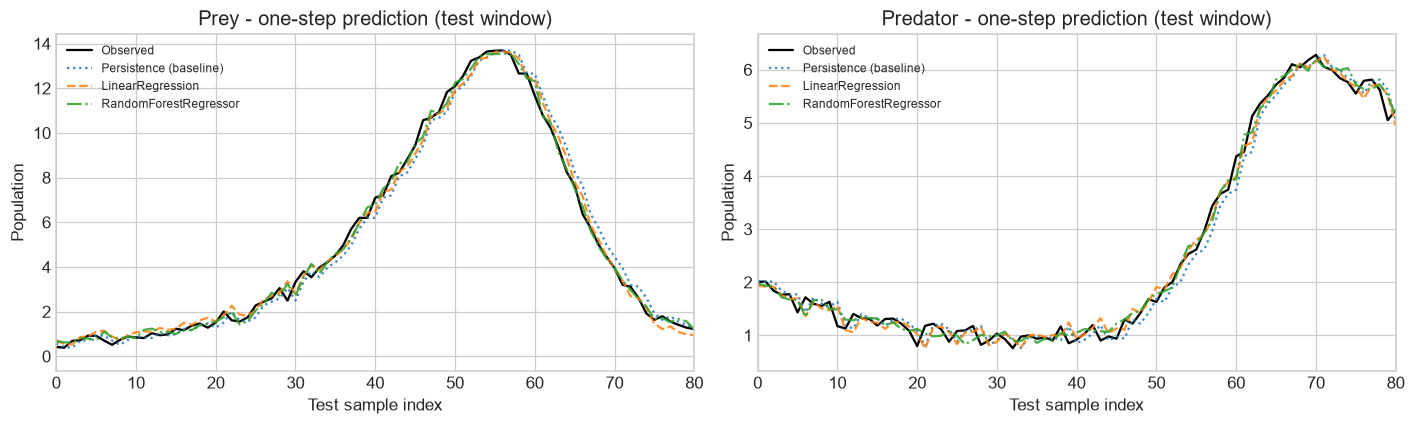

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, species in enumerate(['Prey', 'Predator']):
    ax = axes[i]
    ax.plot(y_test[:, i], color='black', lw=1.5, label='Observed')
    for name, style in [(PERSISTENCE, ':'), (LINEAR, '--'), (FOREST, '-.')]:
        ax.plot(models[name].predict(X_test)[:, i], style, alpha=0.85, label=name)
    ax.set_title(f'{species} - one-step prediction (test window)')
    ax.set_xlabel('Test sample index'); ax.set_ylabel('Population')
    ax.set_xlim(0, 80); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / 'model_comparison.png', dpi=200); plt.show()

**Result (same orbit).** All three models are close (R2 between 0.989 and 0.996 for the prey), which is expected: the baseline alone reaches 0.989. Relative to persistence, the linear model cuts the prey MSE to 0.59x and the forest to 0.36x. On this test the forest looks best, but the test window lies on **the same closed orbit** as the training data, so this result cannot tell a model that learned the dynamics from one that memorised the orbit.

## 4. Unseen orbits

The same models, without retraining, are applied to two other orbits of the same system: a smaller one (inside the training orbit) and a larger one (outside it).

In [6]:
unseen = unseen_orbit_evaluation(models, params, verbose=False)
for label, table in unseen.items():
    print(label); print(table.round(4).to_string()); print()

inner orbit
                        mse_prey  mse_predator  r2_prey  r2_predator  mse_prey_vs_persistence  mse_predator_vs_persistence
model_name                                                                                                                
Persistence (baseline)    0.0887        0.0432   0.9778       0.9398                   1.0000                       1.0000
LinearRegression          0.0706        0.0398   0.9823       0.9445                   0.7957                       0.9226
RandomForestRegressor     0.8271        1.2634   0.7927      -0.7611                   9.3254                      29.2586

outer orbit
                        mse_prey  mse_predator  r2_prey  r2_predator  mse_prey_vs_persistence  mse_predator_vs_persistence
model_name                                                                                                                
Persistence (baseline)    0.4540        0.0842   0.9880       0.9883                   1.0000                     

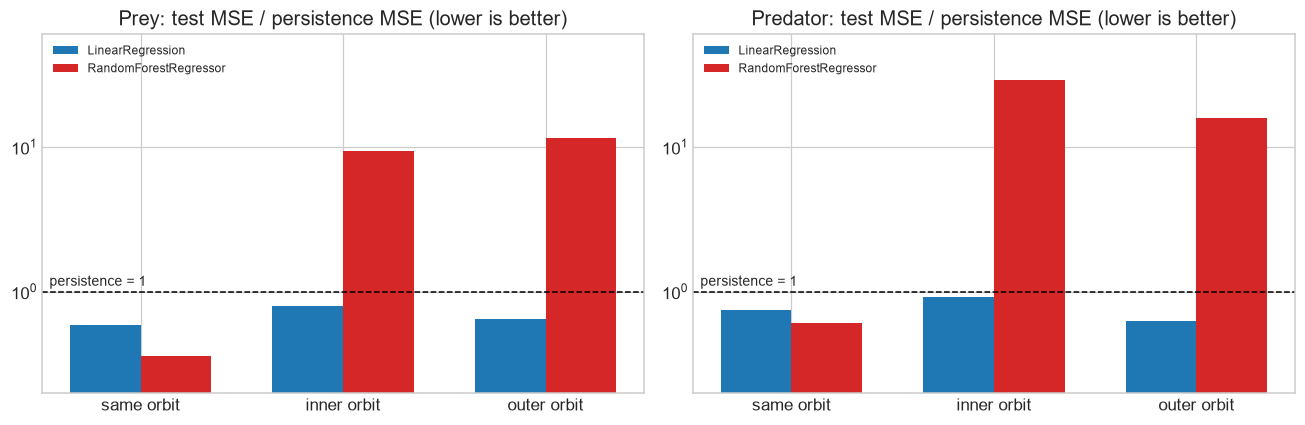

In [7]:
settings = {'same orbit': same_orbit, **unseen}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['mse_prey_vs_persistence', 'mse_predator_vs_persistence'], ['Prey', 'Predator']):
    xs = np.arange(len(settings))
    for k, (name, color) in enumerate([(LINEAR, '#1f77b4'), (FOREST, '#d62728')]):
        vals = [tbl.loc[name, col] for tbl in settings.values()]
        ax.bar(xs + (k - 0.5) * 0.35, vals, 0.35, label=name, color=color)
    ax.axhline(1, color='black', ls='--', lw=1); ax.text(-0.45, 1.1, 'persistence = 1', ha='left', fontsize=9)
    ax.set_yscale('log'); ax.set_ylim(0.2, 60); ax.set_xticks(xs); ax.set_xticklabels(list(settings)); ax.set_title(f'{title}: test MSE / persistence MSE (lower is better)')
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.savefig(FIG / 'generalization.png', dpi=200); plt.show()

**Result (unseen orbits).** The linear model stays better than persistence on both new orbits (MSE ratio 0.80 / 0.92 on the inner orbit, 0.64 / 0.63 on the outer orbit, prey / predator). The random forest is far **worse** than persistence there (ratio 9.3 / 29.3 inner, 11.5 / 15.8 outer): a tree ensemble predicts piecewise-constant values inside the region covered by its training data and cannot extrapolate.

**Conclusion.** These experiments do not show that the ecological interaction requires a non-linear model. They show that (i) a persistence baseline is essential, (ii) within one orbit the models are nearly equivalent, and (iii) the forest's small advantage comes from memorising the training orbit and disappears on other orbits. Near the equilibrium the dynamics are approximately linear, which is why the linear model transfers well. Training on several orbits, or predicting the derivative rather than the next state, would be the next steps.

## 5. Fit to real data: Hudson Bay lynx-hare (1900-1920)

Pelts traded (thousands) serve as a **proxy** for abundance. The model is fitted in these units: alpha and gamma (per year) keep their meaning, whereas beta and delta absorb the pelts-to-population scale and are not biological rates. The initial state is fitted too. The loss (each species divided by its standard deviation) has many local minima, mostly with a wrong cycle period, so the optimisation is restarted from 60 random points.

In [9]:
real_df = load_real_data()
fit = fit_lotka_volterra(real_df, n_starts=60)
p = fit.params
print({k: round(v, 5) for k, v in p.items()})
print(f'Mean squared normalised residual: {fit.cost:.4f}  ({fit.n_near_best}/{fit.n_starts} starts reached the best solution)')
print(f'Fitted cycle period: {fit.period:.2f} years')
print(f'Equilibrium (hare, lynx): ({fit.equilibrium[0]:.1f}, {fit.equilibrium[1]:.1f})  | observed means: ({real_df.hare.mean():.1f}, {real_df.lynx.mean():.1f})')
for sp, m in fit.metrics.items():
    print(f"{sp}: RMSE={m['rmse']:.2f}  R2={m['r2']:.3f}  corr={m['corr']:.3f}")

{'alpha': 0.48232, 'beta': 0.02482, 'delta': 0.0273, 'gamma': 0.91774, 'x0': 35.40077, 'y0': 3.93768}
Mean squared normalised residual: 0.0396  (37/60 starts reached the best solution)
Fitted cycle period: 10.42 years
Equilibrium (hare, lynx): (33.6, 19.4)  | observed means: (34.1, 20.2)
hare: RMSE=4.39  R2=0.956  corr=0.979
lynx: RMSE=3.04  R2=0.965  corr=0.985


Refit on 1900-1912, forecast 1913-1920:
  hare: forecast RMSE=3.25 (constant forecast at the training mean: 24.66), corr=0.998
  lynx: forecast RMSE=3.20 (constant forecast at the training mean: 16.70), corr=0.994


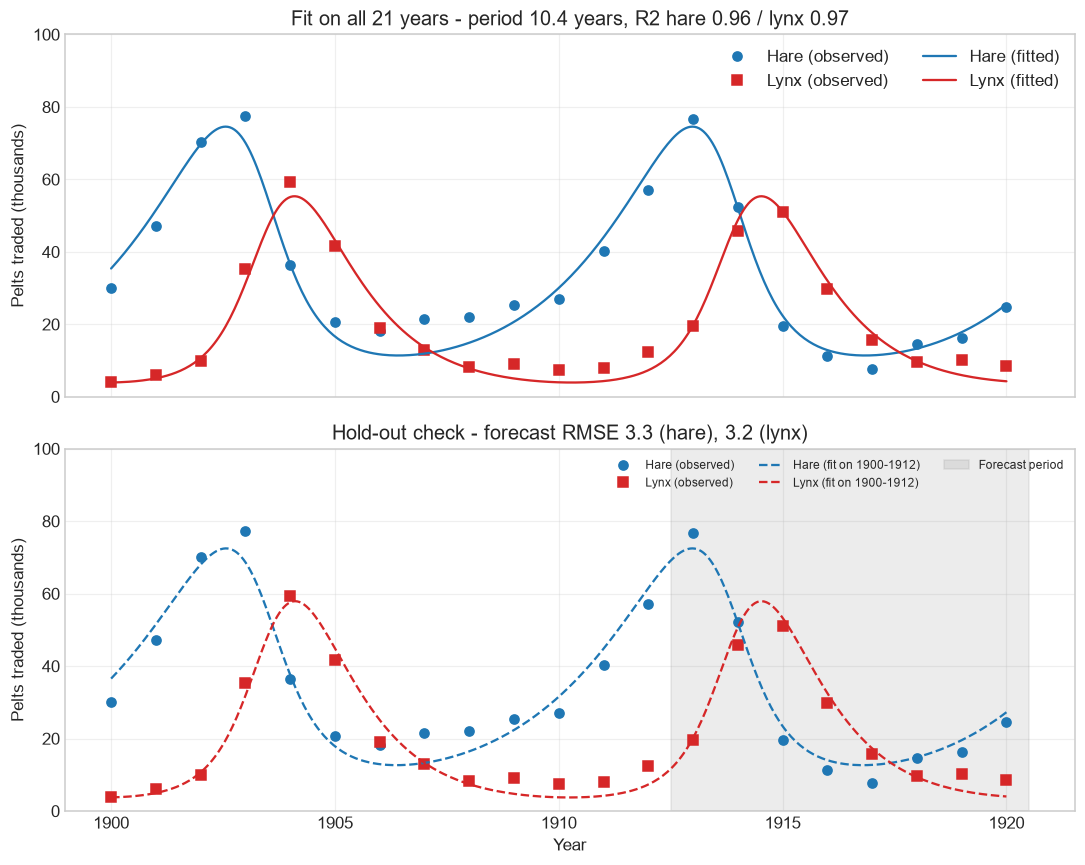

In [10]:
ho = holdout_check(real_df)
n = ho['n_train']
print(f"Refit on {real_df.year.iloc[0]}-{real_df.year.iloc[n-1]}, forecast {real_df.year.iloc[n]}-{real_df.year.iloc[-1]}:")
for sp in ('hare', 'lynx'):
    h = ho[sp]
    print(f"  {sp}: forecast RMSE={h['rmse']:.2f} (constant forecast at the training mean: {h['rmse_mean_baseline']:.2f}), corr={h['corr']:.3f}")
fig = plot_fit(real_df, fit, ho, FIG / 'real_vs_fitted.png'); plt.show()

**Result.** The best fit reproduces the observed ~10-year cycle (fitted period 10.4 years) and both phase lags, with R2 = 0.96 (hare) and 0.97 (lynx). Its equilibrium (33.6, 19.4) is close to the observed means. 37 of the 60 random starts reach this solution; the others stop in local minima, which is why a single start is not enough. In the hold-out check (fit on 1900-1912 only) the forecast RMSE is 3.3 (hare) and 3.2 (lynx) thousand pelts, against 24.7 and 16.7 for a constant forecast.

**Limitations.** Only 21 points per species and a single region; pelt counts are a proxy for abundance; the classical model has no carrying capacity, seasonality or noise model; the hold-out check uses a single split. A natural extension is the Rosenzweig-MacArthur model (logistic prey growth, saturating predation).